In [1]:
# Install the stable-baselines3 and gymnasium libraries directly into the Colab environment
!pip install gymnasium stable-baselines3 torch tensorboard numpy matplotlib --quiet

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.evaluation import evaluate_policy

print("Dependencies successfully installed and imported.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 8.3 MB/s eta 0:00:00
Dependencies successfully installed and imported.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:
class ControlledOscillatorEnv(gym.Env):
    """Custom environment for stabilizing a physical harmonic oscillator."""
    metadata = {"render_modes": ["human"]}

    def __init__(self):
        super().__init__()

        # Continuous control force: F(t) from -10.0 to 10.0
        self.action_space = spaces.Box(low=-10.0, high=10.0, shape=(1,), dtype=np.float32)

        # State space: [Position (u), Velocity (u_dot)]
        self.observation_space = spaces.Box(
            low=np.array([-10.0, -30.0], dtype=np.float32),
            high=np.array([10.0, 30.0], dtype=np.float32),
            dtype=np.float32
        )

        # Physical system parameters (m*u'' + mu*u' + k*u = F)
        self.m = 1.0
        self.mu = 1.0
        self.k = 20.0
        self.dt = 0.02

        self.state = None
        self.steps = 0
        self.max_steps = 200

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # Initialize with structured, out-of-equilibrium states
        initial_position = np.random.uniform(3.0, 5.0)
        initial_velocity = np.random.uniform(-1.0, 1.0)

        self.state = np.array([initial_position, initial_velocity], dtype=np.float32)
        self.steps = 0

        return self.state, {}

    def step(self, action):
        self.steps += 1
        pos, vel = self.state
        force = float(action[0])

        # Physical state evolution (Semi-implicit Euler integration)
        accel = (force - self.mu * vel - self.k * pos) / self.m
        next_vel = vel + accel * self.dt
        next_pos = pos + next_vel * self.dt

        self.state = np.array([next_pos, next_vel], dtype=np.float32)

        # Optimization reward function (minimizes displacement, velocity, and energy)
        reward = -(2.0 * (next_pos ** 2) + 0.5 * (next_vel ** 2) + 0.01 * (force ** 2))

        # Termination conditions
        terminated = bool(
            next_pos < -10.0 or next_pos > 10.0 or
            next_vel < -30.0 or next_vel > 30.0
        )
        truncated = bool(self.steps >= self.max_steps)

        return self.state, float(reward), terminated, truncated, {}

# Instantiate environment
env = ControlledOscillatorEnv()
check_env(env, warn=True)

# Configure the PPO Agent
model = PPO(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    verbose=1,
    tensorboard_log="./ppo_control_logs/"
)

# Evaluate untrained baseline
mean_rev_prev, std_rev_prev = evaluate_policy(model, env, n_eval_episodes=10)
print(f"\nBaseline Reward (Pre-Training): {mean_rev_prev:.2f} +/- {std_rev_prev:.2f}")

# Train the control policy
print("\nTraining control policy network...")
model.learn(total_timesteps=40000, progress_bar=True)

# Evaluate optimized performance
mean_rev_post, std_rev_post = evaluate_policy(model, env, n_eval_episodes=10)
print(f"\nOptimized Reward (Post-Training): {mean_rev_post:.2f} +/- {std_rev_post:.2f}")

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/env_checker.py:515: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: Depreca


Baseline Reward (Pre-Training): -4927.75 +/- 1124.92

Training control policy network...
Logging to ./ppo_control_logs/PPO_1


Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

----------------------------------
| rollout/           |           |
|    ep_len_mean     | 200       |
|    ep_rew_mean     | -5.62e+03 |
| time/              |           |
|    fps             | 628       |
|    iterations      | 1         |
|    time_elapsed    | 3         |
|    total_timesteps | 2048      |
----------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 200         |
|    ep_rew_mean          | -5.31e+03   |
| time/                   |             |
|    fps                  | 495         |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.001747584 |
|    clip_fraction        | 0.00796     |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.42       |
|    explained_variance   | -0.000562   |
|    learning_rate  


Optimized Reward (Post-Training): -5122.13 +/- 794.16


<>:28: SyntaxWarning: invalid escape sequence '\d'
<>:28: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_867/1122342999.py:28: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(time_steps, velocities, label="Velocity ($\dot{u}$)", color="teal", lw=1.5, linestyle="--")
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym

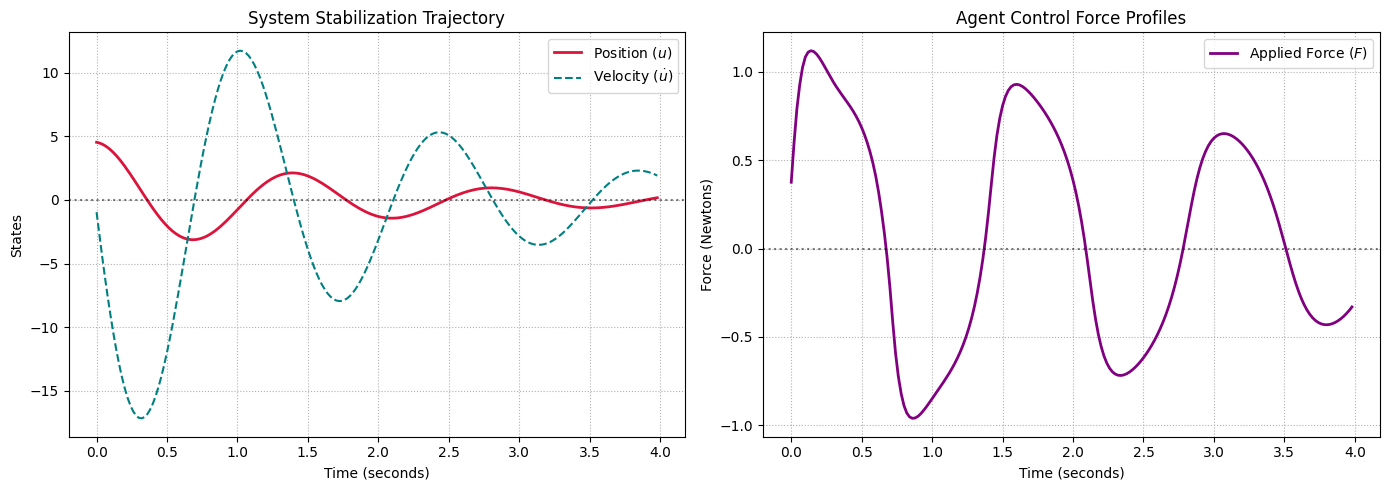

In [3]:
# Run a single evaluation trajectory using the trained model
obs, info = env.reset()
positions = []
velocities = []
forces = []
time_steps = []

current_time = 0.0
for _ in range(200):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)

    positions.append(obs[0])
    velocities.append(obs[1])
    forces.append(action[0])
    time_steps.append(current_time)
    current_time += env.dt

    if terminated or truncated:
        break

# Generate performance graphs
plt.figure(figsize=(14, 5))

# Plot 1: Phase Space Convergence (Position over Time)
plt.subplot(1, 2, 1)
plt.plot(time_steps, positions, label="Position ($u$)", color="crimson", lw=2)
plt.plot(time_steps, velocities, label="Velocity ($\dot{u}$)", color="teal", lw=1.5, linestyle="--")
plt.axhline(0, color="black", linestyle=":", alpha=0.5)
plt.title("System Stabilization Trajectory")
plt.xlabel("Time (seconds)")
plt.ylabel("States")
plt.legend()
plt.grid(True, linestyle=":")

# Plot 2: Control Effort (Force over Time)
plt.subplot(1, 2, 2)
plt.plot(time_steps, forces, label="Applied Force ($F$)", color="purple", lw=2)
plt.axhline(0, color="black", linestyle=":", alpha=0.5)
plt.title("Agent Control Force Profiles")
plt.xlabel("Time (seconds)")
plt.ylabel("Force (Newtons)")
plt.legend()
plt.grid(True, linestyle=":")

plt.tight_layout()
plt.show()